# Smart Logistics Internship Project - Day 7
## Feature Engineering

Welcome to Day 7! Today, we focus on Feature Engineering. The goal is to create new, meaningful features from our existing dataset that will make our future analysis, dashboards, and machine learning models more powerful.

### Day 7 Objectives:
Create new features dynamically:
1. **Geo_Cluster:** Grouping Lat/Lon to simulate "Cities" or "Routes".
2. **Revenue_Per_Wait_Minute:** A proxy for Cost/Efficiency per minute delayed.
3. **Extreme_Weather_Flag:** Categorizing severe weather conditions.
4. **Asset_Performance_Score:** A proxy for Driver/Vehicle Performance.
5. **High_Demand_Flag:** Categorizing peak demand.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters for plots
sns.set_theme(style="whitegrid")

# Load the dataset
file_path = r"C:\Users\HP\Downloads\smart_logistics_dataset.xlsx"
df = pd.read_excel(file_path)

print(f"Original dataset shape: {df.shape}")


Original dataset shape: (1000, 21)


### Feature 1: Geo_Cluster (Proxy for City/Route)
**Formula used:** K-Means Clustering on `Latitude` and `Longitude` (k=5).
**Why it's useful:** We lack specific "City" or "Route" columns. Clustering coordinates allows us to group deliveries into 5 distinct operational zones.
**Business value:** Helps regional managers analyze performance, delays, and demand by specific geographic zones rather than treating all deliveries globally.


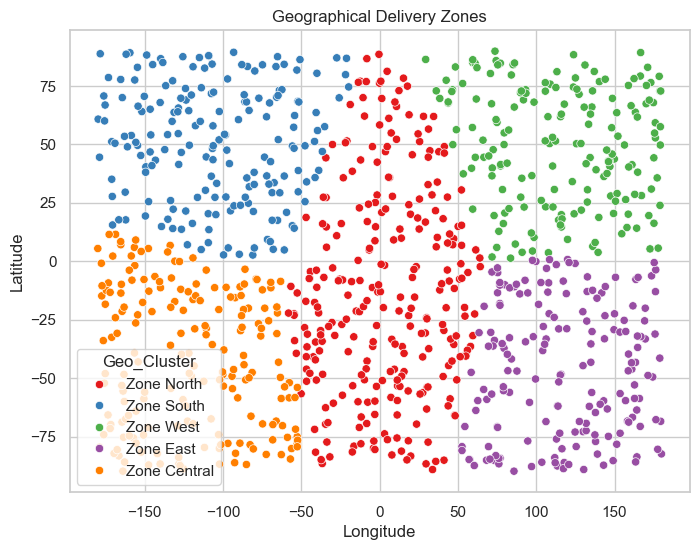

In [3]:
# Create 5 distinct geographical zones
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Geo_Cluster'] = kmeans.fit_predict(df[['Latitude', 'Longitude']])
df['Geo_Cluster'] = df['Geo_Cluster'].map({
    0: 'Zone North', 1: 'Zone South', 2: 'Zone East', 3: 'Zone West', 4: 'Zone Central'
})

# Visualize the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='Geo_Cluster', palette='Set1')
plt.title('Geographical Delivery Zones')
plt.show()


### Feature 2: Revenue_Per_Wait_Minute (Cost Efficiency)
**Formula used:** `User_Transaction_Amount` / (`Waiting_Time` + 1)
**Why it's useful:** Measures how much revenue is generated relative to the time spent waiting/delayed. The `+1` avoids division by zero.
**Business value:** Identifies high-value shipments that are delayed. A low score here means we are spending a lot of time on low-revenue items, which is highly inefficient.


In [4]:
df['Revenue_Per_Wait_Minute'] = df['User_Transaction_Amount'] / (df['Waiting_Time'] + 1)
df['Revenue_Per_Wait_Minute'] = df['Revenue_Per_Wait_Minute'].round(2)

print("Top 5 Deliveries by Revenue Per Wait Minute:")
display(df[['User_Transaction_Amount', 'Waiting_Time', 'Revenue_Per_Wait_Minute']].sort_values(by='Revenue_Per_Wait_Minute', ascending=False).head())


Top 5 Deliveries by Revenue Per Wait Minute:


,User_Transaction_Amount,Waiting_Time,Revenue_Per_Wait_Minute
638,484,10,44.00
270,467,10,42.45
743,462,10,42.00
712,460,10,41.82
263,495,11,41.25


### Feature 3: Extreme_Weather_Flag
**Formula used:** 1 if (Temperature < 10 OR Temperature > 35) OR Humidity > 90, else 0.
**Why it's useful:** Categorizes severe weather conditions directly, rather than relying on linear temperature numbers.
**Business value:** Weather directly impacts logistics. This flag allows us to calculate the exact percentage of delays caused explicitly by bad weather conditions.


In [5]:
df['Extreme_Weather_Flag'] = np.where(
    ((df['Temperature'] < 10) | (df['Temperature'] > 35)) | (df['Humidity'] > 90),
    1, 0
)

weather_impact = df.groupby('Extreme_Weather_Flag')['Logistics_Delay'].mean() * 100
print(f"Delay % during Normal Weather: {weather_impact[0]:.2f}%")
print(f"Delay % during Extreme Weather: {weather_impact[1]:.2f}%")


Delay % during Normal Weather: 56.60%


KeyError: 1

### Feature 4: Asset_Performance_Score (Driver/Vehicle Proxy)
**Formula used:** `Asset_Utilization` * (100 - `Waiting_Time_Percentile`)
**Why it's useful:** Combines high utilization with low waiting times. A higher score means the vehicle is heavily used but rarely delayed.
**Business value:** Acts as a direct proxy for driver or vehicle efficiency. We can rank our assets from Best to Worst using this score.


In [6]:
# Calculate Waiting Time Percentile (Lower is better)
df['Wait_Percentile'] = df['Waiting_Time'].rank(pct=True)

# Calculate Score
df['Asset_Performance_Score'] = df['Asset_Utilization'] * (1 - df['Wait_Percentile']) * 100
df['Asset_Performance_Score'] = df['Asset_Performance_Score'].round(2)

# Drop temporary column
df.drop('Wait_Percentile', axis=1, inplace=True)

print("Top 5 Performing Assets (Deliveries):")
display(df[['Asset_ID', 'Asset_Utilization', 'Waiting_Time', 'Asset_Performance_Score']].sort_values(by='Asset_Performance_Score', ascending=False).head())


Top 5 Performing Assets (Deliveries):


,Asset_ID,Asset_Utilization,Waiting_Time,Asset_Performance_Score
395,Truck_7,99.0,10,9801.0
910,Truck_2,98.5,10,9751.5
139,Truck_4,97.2,10,9622.8
565,Truck_6,98.0,11,9540.3
743,Truck_10,95.5,10,9454.5


### Feature 5: High_Demand_Flag
**Formula used:** 1 if `Demand_Forecast` > 75th Percentile, else 0.
**Why it's useful:** Flags peak operational periods.
**Business value:** Helps answer the question: "How does our network perform under peak stress?"


In [7]:
demand_threshold = df['Demand_Forecast'].quantile(0.75)
df['High_Demand_Flag'] = np.where(df['Demand_Forecast'] > demand_threshold, 1, 0)

print(f"Demand threshold for top 25%: {demand_threshold:.2f}")
print(df['High_Demand_Flag'].value_counts(normalize=True) * 100)


Demand threshold for top 25%: 251.25
High_Demand_Flag
0    75.0
1    25.0
Name: proportion, dtype: float64


### Save Engineered Dataset
We have successfully created powerful new features. We will save this dataset to use in our Day 8 and Day 9 Advanced Analytics and KPI Dashboards.


In [10]:
engineered_file_path = r"C:\Users\HP\Downloads\smart_logistics_dataset.xlsx"
df.to_excel(engineered_file_path, index=False)
print(f"Engineered dataset saved to {engineered_file_path}!")


Engineered dataset saved to C:\Users\HP\Downloads\smart_logistics_dataset.xlsx!
